
# Security and Privacy (CC2009) - 25/26
## ASSIGNMENT #1: Performance Benchmarking of Cryptographic Mechanisms
## PL1 - Elements: Amanda Lucas (202400455), Aly Filho (202401045) e Sílvia Pinto (202405988)


#### A. Generate random text files with the following sizes: 8, 64, 512, 4096, 32768, 262144, 2097152:
  &emsp;Done in ../03 - data<br>
  &emsp;We use the **urandom** from **OS** (Python) to generate random files; can be seen in **../02 - scripts/gen_files.py**

In [21]:
import os                                                            # For navegation in the file folders.
import sys                                                           # For navegation in the file folders.
import secrets                                                       # To use entropy for true randomness.
from AES_ctr import *                                                # Auxiliar functions for the AES.
from aux_funcs import *                                              # Auxiliar functions for the RSA.
from cryptography.hazmat.primitives.ciphers import Cipher            # To create a cipher for the AES.
from cryptography.hazmat.primitives.ciphers import algorithms, modes # To define the algorithm and mode of our cipher.
from cryptography.hazmat.primitives.asymmetric import rsa            # Generating keys.
from cryptography.hazmat.primitives import hashes                    # Function H(n, r).
import matplotlib.pyplot as plt                                      # Generating graphs.
import seaborn as sns                                                # Improving graph visualization.
import pandas as pd                                                  # To create a dataframe of our results.

#### B. Encrypt and decrypt random files with AES in Counter Mode, using the code that you wrote previously:
&emsp;First thing is to define 2 functions, one to encrypt and another one to decrypt, using the cryptography library from python: We will use Cipher to define a cipher with AES algorithms from algorithms in CTR mode from modes. That can been seen in **../01 - source/aes_ctr.py**<br>
&emsp;Here function 1 receives m (plaintext), the key and the nonce. It returns c (ciphertext). The function 2 receives c (ciphertext), the key and the nonce and returns the original text m (plaintext):

In [ ]:
def my_encrypt_aes_ctr(plaintext, key, nonce):
    alg = algorithms.AES(key) 
    mode = modes.CTR(nonce) 
    cypher = Cipher(alg,mode) 
    encrypt = cypher.encryptor()  
    return encrypt.update(plaintext) + encrypt.finalize() 

def my_decrypt_aes_ctr(ciphertext, key, nonce):
    alg = algorithms.AES(key) 
    mode = modes.CTR(nonce) 
    cypher = Cipher(alg,mode) 
    decrypt = cypher.decryptor()
    return decrypt.update(ciphertext) + decrypt.finalize()

&emsp;To ensure statistical significance, we automated the benchmarking process using **Pandas** and **NumPy**. We performed repeated executions over the same files to observe temporal variance, and across multiple randomly generated files of fixed sizes to evaluate the algorithm's consistency regardless of the input data. For intuitive graphical analysis we use **Matplotlib** and **Seaborn** libraries.

In [ ]:
sys.path.append('../01 - source')

##### Question B.1) Do results change if you run a fixed algorithm over the same file multiple times?

&emsp;Here we are fixing the algorithm over one unique file; that can be seen in function **plot_variation_same_file** in **aes_ctr.py**, and we encrypt and decrypt this fixed file various times.<br>
&emsp;To ensure statistical significance, we chose a sample size of **n = 30** repetitions for each cryptographic operation. According to the Central Limit Theorem, a sample size of 30 is sufficient to approximate a normal distribution, allowing for reliable calculations of the standard deviation and confidence intervals.

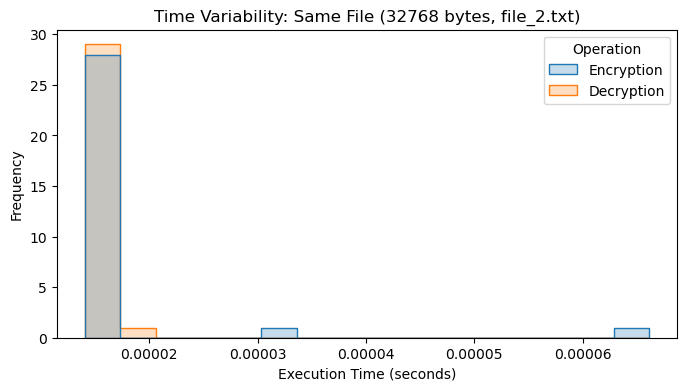

In [4]:
plot_variation_same_file(df, 32768, 'file_2.txt')

&emsp;For a better analysis, let's take a look at the performance of a 32768 Bytes size file (the intermediary size) - but it can be done with any file size, by just calling the function with the desired size as the parameter. Studying these graphics, we can conclude:
- **Yes, the results change if you run a fixed algorithm over the same file multiple times.** That may seen strange because the AES-CTR is a deterministic algorithm, that is, the same input generates the same output with the same calculations. So, why do the times change in the 30 tests of encrypt and decrypt? That's not the algorithm's fault; the variation occurs because of the computational environment, e.g. the O.S. is doing many things at the same time and, while the Python script is working, other procedures are happening which can cause noise in our data  (called CPU jitter). In the graphics we can notice:
    1) The big bar: Shows the real and pure time of algorithm, in almost all tests (28 or 29 times). This is the execution time of our algorithm practically without any system noise.
    2) The little bars: They are outliers, and show that sometimes the OS parallels procedures which can "dirty" the data times.

&emsp;Now let's analyze the time variability for each one of the 7 defined file sizes:

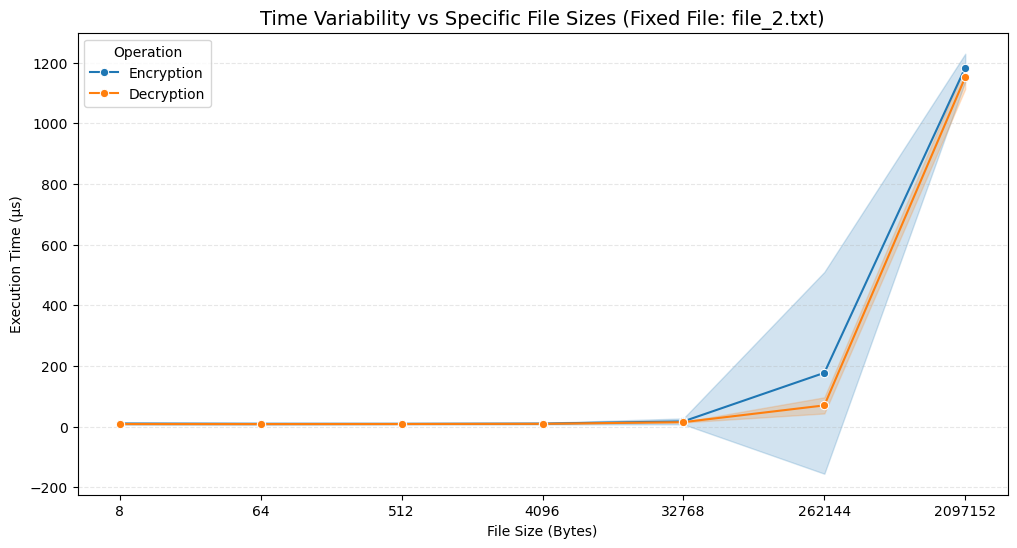

In [5]:
plot_variation_fixed_file_categorical(df,'file_2.txt')

&emsp;The performance benchmarking of AES-256 in Counter Mode (CTR) demonstrates a clear linear correlation between file size and execution time, confirming the algorithm's O(n) efficiency. While the curves for encryption and decryption are theoretically symmetric, the increased standard deviation (shaded area) observed at the 2,097,152-byte mark highlights the impact of environmental noise and CPU jitter on larger workloads. Despite using a deterministic algorithm and a fixed file (file_2.txt), the measured variability across 30 iterations proves that execution times are susceptible to OS-level scheduling and memory latency, which become more pronounced as the processing window expands.

##### Question B.2) And what if you run an algorithm over multiple randomly generated files of fixed size?

&emsp;Now we're comparing the algorithm performance in 10 different random files. That can be seen in function **plot_comparison_fixed_size** in aes_ctr.py file

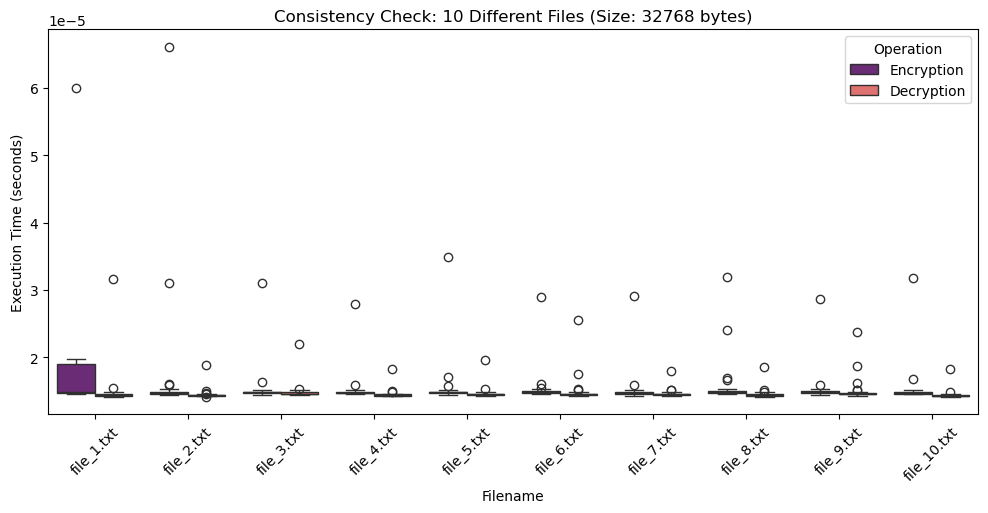

In [6]:
plot_comparison_fixed_size(df,32768)

&emsp; We're looking at the 262144 Bytes size, but it can be done with any file size by just calling the function with the desired size as a parameter. Studying these graphics, we can conclude:
- **No, the algorithmic execution time does not change based on the file's content.** Any variations observed between different files of the same size are purely the result of the environmental noise (CPU jitter) already proven in Question B.1, not a change in the algorithm's complexity.<br>
- Because AES in Counter Mode (AES-CTR) operates on raw byte blocks, it is completely blind to the actual content (data entropy) of the files. Encrypting a 32 KB file of structured text requires the exact same number of mathematical operations as encrypting a 32 KB file of random noise. Therefore, while the measured time fluctuates due to OS background tasks (as seen in the spikes of file_8 for 32 KB or file_1 for 2 MB), the theoretical and practical computational workload of the algorithm remains perfectly constant.

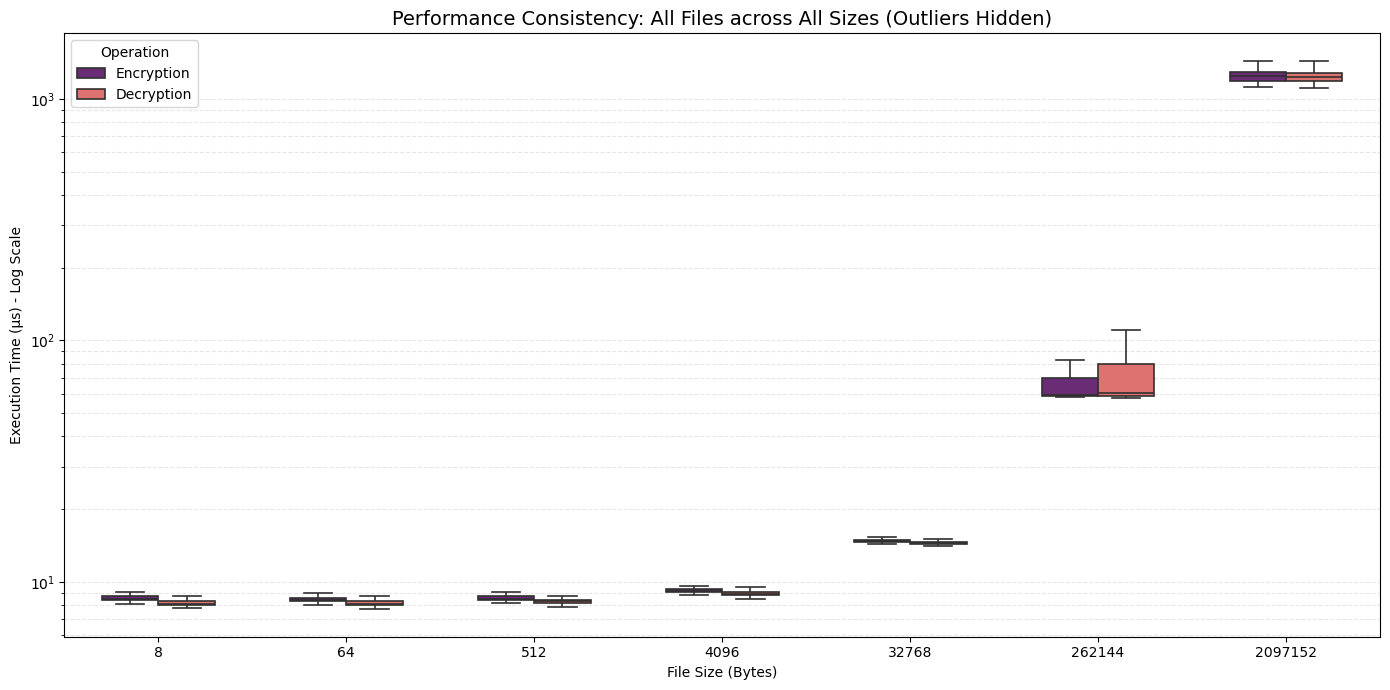

In [7]:
plot_consistency_all_sizes_us(df)

&emsp;This plot serves as the primary evidence for statistical significance and performance consistency across the entire dataset. By aggregating all 10 random files per size into a single categorical view, it demonstrates that AES-CTR execution time is strictly dependent on the input size (O(n)) and independent of the specific data content, as shown by the aligned medians across the 7-byte size groups. The use of a logarithmic scale on the Y-axis is crucial to visualize the full range of measurements from 8 B to 2 MB simultaneously, while the hidden outliers (achieved via showfliers=False) clarify the core distribution, proving that despite environmental jitter, the algorithm maintains a highly stable and symmetric performance profile for both encryption and decryption.

##### Final Analysis - Cross-size graphic:
<br>For the end of the AES-CTR analysis, let's put all performances times by file size side by side in a log scale graphic (using the mean of the 30 iterations in each 10 files of each byte size):

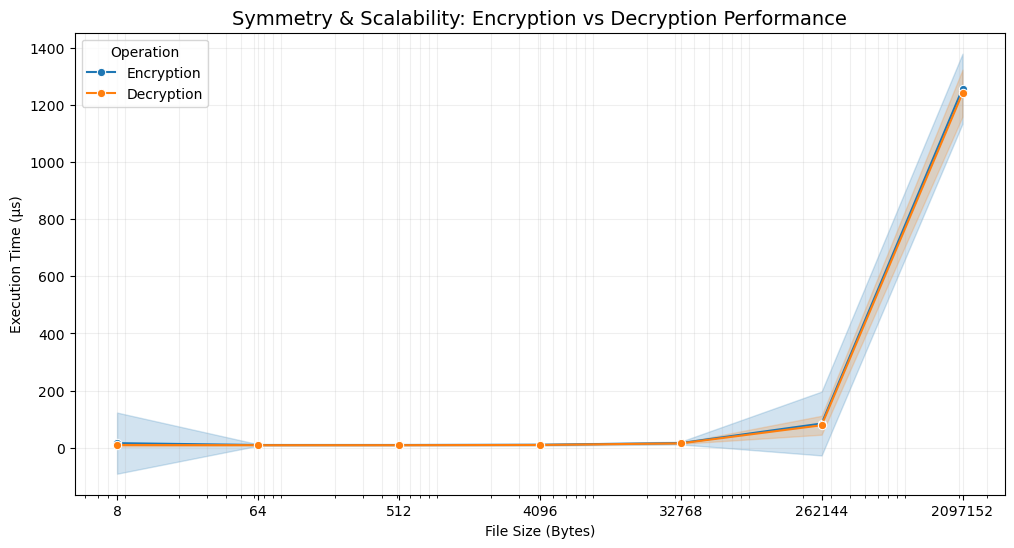

In [ ]:
plot_final_scalability(df)

&emsp;Studying this graphic, we can conclude:
1) **Algorithmic Symmetry:** The near-perfect overlap of the encryption (blue) and decryption (orange) plot lines demonstrates the symmetric workload of the AES Counter Mode. Because both operations simply generate a keystream (Key + Nonce) and apply an XOR bitwise operation against the payload, they are computationally indistinguishable and require the exact same execution time.
2) **Linear Time Complexity O(n):** While the plot visually resembles an exponential curve, it is plotted against a logarithmic X-axis. Mathematically, a straight linear progression plotted on a logarithmic scale produces this exact curve. This empirically proves that AES-CTR scales linearly **O(n)**: the execution time grows in direct, steady proportion to the input byte size, without exponential performance degradation.
3) **Variance Expansion:** The shaded confidence intervals (representing standard deviation across the n=30 sample size) visually widen as the file size increases. This corroborates our earlier findings: larger files demand longer execution windows and memory fetches (RAM), exponentially increasing the likelihood of Operating System interruptions, which causes the execution times to fluctuate more broadly than with smaller payloads.


---

#### C. Implementation of the RSA function and its inverse

&emsp;We start by creating the functions that will mask and unmask our private key. For the encryption, we use the formula:<br>
&emsp;&emsp;**Enc(public_key, r_int) = r_int ^ e (mod n)**, where e is the exponent and n is the public number.<br>

&emsp;And, for the inverse function that decrypts, we use the formula: <br>
&emsp;&emsp;**Dec(private_key, c_r) = c_r ^ d (mod n)**, where d is the number such that e * d (mod v) = 1

In [ ]:
def rsa_trapdoor_permutation(public_key, r_int):                     # Pure RSA.
    e = public_key.public_numbers().e
    n = public_key.public_numbers().n
    return pow(r_int, e, n)

def rsa_inverse_trapdoor(private_key, c_r):                          # Inverse function of the one above.
    d = private_key.private_numbers().d
    n = private_key.private_numbers().public_numbers.n
    return pow(c_r, d, n)

&emsp;Having the RSA functions ready, we can now define a way to encrypt and decrypt a message.

For encryption:<br>
&emsp;1. Apply the trapdoor permutation to encrypt.<br>
&emsp;2. Transform r from bits to bytes, so that we can apply SHA 256 on it.<br>

For decryption:<br>
&emsp;3. Apply the inverse of the trapdoor permutation to decrypt.<br>
&emsp;4. Transform decrypted r from bits to bytes.<br>

Both operations:<br>
&emsp;5. Divide message into blocks of 32 bytes.<br>
&emsp;6. Hash each block, measuring the hashing time.<br>
&emsp;7. Add the resulting text block to our group of blocks, applying an XOR with the original block.<br>

In [ ]:
def custom_encrypt_decrypt(private_key, public_key, message, mode, r):
    l_size = 32                                                      # SHA 256 output size.
    ciphertext_blocks = []    
    if (mode == "Encrypting"):  
        enc_message = message
        rsa_start_time = time.perf_counter()
        rsa_r = rsa_trapdoor_permutation(public_key, r)              # STEP 1.: Apply the trapdoor permutation to r.
        rsa_end_time = time.perf_counter()
        rsa_r_bytes = rsa_r.to_bytes(256, 'big')                     # STEP 2.1.: Transform encrypted r from bits into bytes (2048 bits = 256 bytes).
        ciphertext_blocks += [rsa_r_bytes]     
        r_bytes = r.to_bytes(256, 'big')                             # STEP 2.2.: Transform original r from bits into bytes, to use in hashing operation.

    elif (mode == "Decrypting"):
        rsa_start_time = time.perf_counter()
        c_r = int.from_bytes(message[:256], 'big')
        int_r = rsa_inverse_trapdoor(private_key, c_r)               # STEP 3.: Apply the inverse function to encrypted r.
        rsa_end_time = time.perf_counter()
        r_bytes = int_r.to_bytes(256, 'big')                         # STEP 4.: Transform the decrypted r from bits to bytes.
        enc_message = message[256:]

    rsa_time = rsa_end_time - rsa_start_time
    hash_time = 0
    for i in range(0, len(enc_message), l_size):                
        block_index = i // l_size
        chunk = enc_message[i : i + l_size]                          # STEP 5.: Divide our message into blocks of 32 bytes.
        
        digest = hashes.Hash(hashes.SHA256())              
                                                                     # STEP 6.: Hash each block, measuring the hashing time.
        hash_update_time = measure_performance_time(digest.update, block_index.to_bytes(4, 'big') + r_bytes)[0]
        hash_finalize_time, block_with_hash = measure_performance_time(digest.finalize)
        hash_time += hash_update_time + hash_finalize_time
        
        ciphertext_blocks.append(xor_bytes(chunk, block_with_hash))  # STEP 7.: Apply XOR between original block and hashed block, and append to result block.

    return b"".join(ciphertext_blocks), hash_time, rsa_time          # Return the full resulting message and the time measurements, for future performance analysis.

&emsp;Now, we simply need to generate the private key and its corresponding public key, to perform encryption and decryption.

In [ ]:
private_key = rsa.generate_private_key(public_exponent=65537, key_size=2048)
public_key = private_key.public_key()
n = public_key.public_numbers().n                                    # STEP 1.: Get public number n to generate r.
r = secrets.randbelow(n)                                             # STEP 2.: Randomize a number r to be encrypted.

&emsp;The main function processes all the files of a given size, either decrypting or encrypting them. It also registers the time measurements for each file and returns them.

In [ ]:
def main(mode, base_dir, file_size):
    all_files, folder_path = get_files(base_dir, file_size, mode)    # Get 10 files for the current size andthe path of their parent folder.
    total_time = 0
    rsa_times = []
    hash_times = []
    for file_name in all_files:                                      # For each of the files, perform encryption or decryption.
        file_path = os.path.join(folder_path, file_name)

        with open(file_path, "rb") as f: 
            data = f.read()

        ciphertext, hash_time, rsa_time = custom_encrypt_decrypt(private_key, public_key, data, mode, r)
        rsa_times += [rsa_time]
        hash_times += [hash_time]
        total_time += rsa_time                                                     
                                                                     # Save the encrypted files in a new folder.        
        output_dir = save_in_results(ciphertext, base_dir, file_size, file_name, mode)
    return rsa_times, hash_times                                     # Return the RSA and SHA 256 execution times for each file.

&emsp;We are ready to process our files. Starting from our base directory, we encrypt and decrypt each of the 10 files for all the available sizes, using RSA encryption and SHA 256 hashing. <br>
&emsp;To visualize and study our results, we create a database with the time measurements by file size and operation type.

In [ ]:
base_dir = os.getcwd()                                               # We start from our current directory and work our way to the location of the files.
sizes = ["8", "64", "512", "4096", "32768", "262144", "2097152"]
results = {size: {} for size in sizes}

for size in sizes:
        for i in range(0,10):
            rsa_enc, hash_enc = main("Encrypting", base_dir, size)
            rsa_dec, hash_dec = main("Decrypting", base_dir, size)
            results[size][i] = {'RSA Encryption': rsa_enc[i], "Hash Encryption": hash_enc[i], 'RSA Decryption': rsa_dec[i], "Hash Decryption": hash_dec[i]}
        
data_pd = []                                                        # For creating the dataframe.

for size, files in results.items():
    for index, metrics in files.items():
        for operation, times in metrics.items():
                data_pd.append({
                    "Size_Bytes": int(size),                        # First column of our dataframe is the file size.
                    "Filename": "file_" + str(index+1) + ".txt",    # For each file size, we have 10 different file names.
                    "Execution_Time": times,                        # Each execution originates different execution times.
                    "Operation": operation                          # Separates encrypting, decrypting, RSA and SHA as different operations.
                })

df_data = pd.DataFrame(data_pd)                                     # Dataframe with all of our time measurement.

&emsp;With our dataframe ready, it becomes simple to create plots that give us a visual comparison between the execution times.

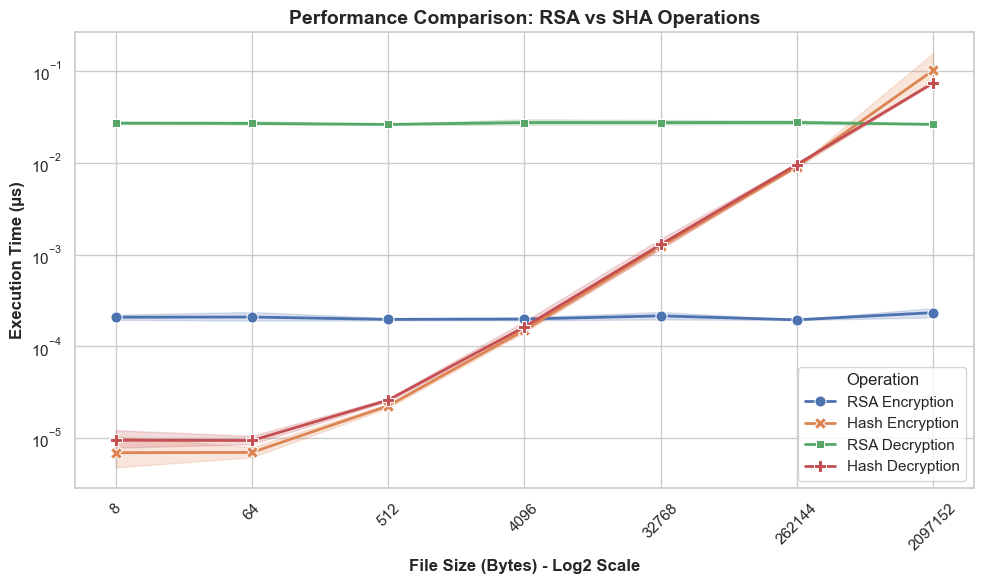

In [ ]:
df_data['Size_Bytes'] = pd.to_numeric(df_data['Size_Bytes'])
df_data['Execution_Time'] = pd.to_numeric(df_data['Execution_Time'])

plt.figure(figsize=(10, 6))                                         # Plot design configurations for cleaner display.
sns.set_theme(style="whitegrid")

ax = sns.lineplot(
    data=df_data,
    x='Size_Bytes',                                                 # The x grid of our plot is the size of the files.
    y='Execution_Time',                                             # The y grid is the execution time for each of the file sizes.
    hue='Operation',                                                # We distinguish different operations by colors,
    style='Operation',                                              # and by different line styles as well.
    markers=True,     
    dashes=False,
    linewidth=2,
    markersize=8
)

ax.set_xscale('log', base=2)                                        # For better visualization, we set the scale of the x grid to log (base 2),
ax.set_yscale('log', base=10)                                       # and we set the y grid scale to log (base 10).

                                                                    # Adding labels to our plot
plt.xlabel('File Size (Bytes) - Log2 Scale', fontsize=12, fontweight='bold')
plt.ylabel('Execution Time (\u00B5s)', fontsize=12, fontweight='bold') 
plt.title('Performance Comparison: RSA vs SHA Operations', fontsize=14, fontweight='bold')

sizes = [8, 64, 512, 4096, 32768, 262144, 2097152]                  # Configure x grid to mark the exact values of our file sizes
plt.xticks(sizes, sizes, rotation=45)

plt.tight_layout()
plt.show()

&emsp;From this graph, we can clearly see that the RSA functions, both for encrypting and decrypting, do not depend on the file size or content; they are constant, since we use the same number r for all of them, with the fixed size of 256 bytes.<br>
&emsp;About the time difference between the encrypting and decrypting of the RSA function, the process to recover the number R takes a lot more computacional power because the exponent used is the value "d" of the private key (this number usually takes 256 bytes, and to generate the key, the exponent used only has 3 bytes). <br>
&emsp;For the SHA 256 hashing, the situation changes. This hash function varies with every message size. This means that, for bigger file sizes, the number of blocks of the partition is much higher as well - this results in having to iterate our hashing function for the much greater number of blocks, making the execution time grow.

In [ ]:
df_RSA = df_data[df_data['Operation'].str.startswith("R")]
df_SHA = df_data[df_data['Operation'].str.startswith("H")]
df['Operation'] = df['Operation'].replace({
    'Encryption': 'AES Encryption', 
    'Decryption': 'AES Decryption'
})

,Size_Bytes,Filename,Execution_Time,Operation
0,8,file_1.txt,0.000207,RSA Encryption
2,8,file_1.txt,0.026078,RSA Decryption
4,8,file_2.txt,0.000190,RSA Encryption
6,8,file_2.txt,0.027824,RSA Decryption
8,8,file_3.txt,0.000193,RSA Encryption


      Size_Bytes     Filename  Execution_Time       Operation
0              8   file_1.txt        0.000207  RSA Encryption
1              8   file_1.txt        0.026078  RSA Decryption
2              8   file_2.txt        0.000190  RSA Encryption
3              8   file_2.txt        0.027824  RSA Decryption
4              8   file_3.txt        0.000193  RSA Encryption
...          ...          ...             ...             ...
4335     2097152  file_10.txt        0.001289  AES Decryption
4336     2097152  file_10.txt        0.001358  AES Decryption
4337     2097152  file_10.txt        0.001196  AES Decryption
4338     2097152  file_10.txt        0.001245  AES Decryption
4339     2097152  file_10.txt        0.001236  AES Decryption

[4340 rows x 4 columns]


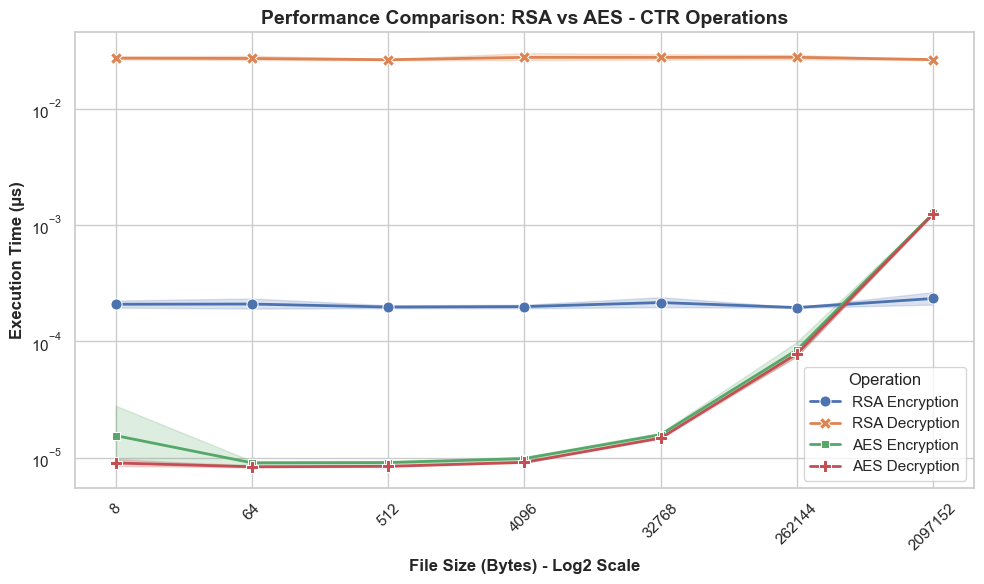

In [ ]:
# 1. Combina os dois DataFrames (df_RSA e df) em um único DataFrame chamado df_data
df_data = pd.concat([df_RSA, df], ignore_index=True)

# Aplica o replace no df_data usando um ÚNICO dicionário
df_data['Operation'] = df_data['Operation'].replace({
    'Encryption': 'AES Encryption', 
    'Decryption': 'AES Decryption'
})

# 3. Configurações de design da plotagem
plt.figure(figsize=(10, 6))                                        
sns.set_theme(style="whitegrid")

# 4. Geração do gráfico de linhas
ax = sns.lineplot(
    data=df_data,
    x='Size_Bytes',                                                
    y='Execution_Time',                                            
    hue='Operation',                                               
    style='Operation',                                             
    markers=True,     
    dashes=False,
    linewidth=2,
    markersize=8
)

# 5. Escalas logarítmicas
ax.set_xscale('log', base=2)                                       
ax.set_yscale('log', base=10)                                      

# 6. Adição de títulos e rótulos
plt.xlabel('File Size (Bytes) - Log2 Scale', fontsize=12, fontweight='bold')
plt.ylabel('Execution Time (\u00B5s)', fontsize=12, fontweight='bold') 
plt.title('Performance Comparison: RSA vs AES - CTR Operations', fontsize=14, fontweight='bold')

# 7. Configuração das marcações do eixo X
sizes = [8, 64, 512, 4096, 32768, 262144, 2097152]                  
plt.xticks(sizes, sizes, rotation=45)

# 8. Ajuste de layout e exibição
plt.tight_layout()
plt.show()

In [17]:
df_data.head()

,Size_Bytes,Filename,Execution_Time,Operation
0,8,file_1.txt,0.000207,RSA Encryption
1,8,file_1.txt,0.026078,RSA Decryption
2,8,file_2.txt,0.000190,RSA Encryption
3,8,file_2.txt,0.027824,RSA Decryption
4,8,file_3.txt,0.000193,RSA Encryption
